In [1]:
import pandas as pd

ames_housing = pd.read_csv("../datasets/ames_housing_no_missing.csv")
target_name = "SalePrice"
data = ames_housing.drop(columns=target_name)
target = ames_housing[target_name]

In [2]:
numerical_features = [
    "LotFrontage", "LotArea", "MasVnrArea", "BsmtFinSF1", "BsmtFinSF2",
    "BsmtUnfSF", "TotalBsmtSF", "1stFlrSF", "2ndFlrSF", "LowQualFinSF",
    "GrLivArea", "BedroomAbvGr", "KitchenAbvGr", "TotRmsAbvGrd", "Fireplaces",
    "GarageCars", "GarageArea", "WoodDeckSF", "OpenPorchSF", "EnclosedPorch",
    "3SsnPorch", "ScreenPorch", "PoolArea", "MiscVal",
]

data_numerical = data[numerical_features]

In [3]:
# for Ridge regression with alpha=0, meaning no regularization
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_validate
from sklearn.pipeline import make_pipeline

model = make_pipeline(
    StandardScaler(),
    Ridge(alpha=0)
)

cv_results = cross_validate(
    model,
    data_numerical,
    target,
    cv=10,
    scoring="neg_mean_absolute_error",
    return_estimator=True,
    n_jobs=-1,
)

for estimator in cv_results["estimator"]:
    ridge = estimator.named_steps["ridge"]
    print(ridge.coef_)

[-6.97463990e+03 -2.59752160e+03 -2.12409799e+04  4.01348259e+19
  1.43425357e+19  3.88531635e+19 -3.88385026e+19 -1.45797954e+19
 -1.63202450e+19 -1.79002122e+18  1.98200620e+19 -1.55983066e+04
 -8.35995545e+03  1.33993845e+04  1.00805221e+01  3.75474184e+04
 -9.74173312e+03  5.80639180e+03 -1.35744764e+03 -3.45232435e+03
  1.59381510e+04 -3.40836140e+03  6.59003649e+03  5.06696115e+03]
[ 4.49909156e+02  7.07267484e+02  6.48906199e+03  5.62418848e+18
  1.92350436e+18  5.37373114e+18 -5.40546176e+18 -6.81314634e+18
 -7.63077990e+18 -7.21261574e+17  9.24676603e+18 -1.18779838e+04
 -9.27001448e+03  1.54351708e+04  2.32452795e+03  2.12900762e+04
 -5.01556673e+03  3.98978167e+03  2.51846714e+03 -2.83841596e+03
 -3.83179381e+02  8.53698857e+02 -1.43541149e+03  5.80962101e+02]
[-1.96792593e+02  9.14746285e+02  6.96194207e+03  1.24474502e+18
  4.37279106e+17  1.20940357e+18 -1.19796667e+18 -1.07466878e+18
 -1.19676715e+18 -1.36504933e+17  1.45001949e+18 -1.30715590e+04
 -1.06246743e+04  1.378

In [4]:
# for Ridge regression with alpha=1.0, meaning some regularization
model = make_pipeline(
    StandardScaler(),
    Ridge(alpha=1.0)
)

cv_results = cross_validate(
    model,
    data_numerical,
    target,
    cv=10,
    scoring="neg_mean_absolute_error",
    return_estimator=True,
    n_jobs=-1,
)

for estimator in cv_results["estimator"]:
    ridge = estimator.named_steps["ridge"]
    print(ridge.coef_)

[  -476.7540384    1395.26586767   7657.72795825   8808.08423315
   -269.70376794   2933.25031527  11936.83367719  10101.97636022
  11966.64015307  -1560.40361852  17143.74513157 -11422.59695234
 -10983.96348878  11978.96162655   3343.7095444   20867.28638326
  -1862.72746276   4547.28709081   2195.08577177  -2102.82343736
   1697.85693969   1685.34739628  -2024.61947363    378.54494027]
[ -1014.94135219   1150.58072418   6620.70054509   8565.02416985
    -70.05322913   3087.95534022  11956.50013454   9935.65319997
  11841.46688672  -2770.56990153  16876.64429315 -11751.83609777
 -11580.77539902  12689.40176564   3230.65116135  20329.01517192
  -2320.14134811   5400.15174877   1700.73600103  -3120.96520715
    883.47722444    740.77176377  -1786.46151149    297.45136653]
[  -150.87638715    493.59127029   6843.02466385   8498.0922879
   -658.03903402   3238.45752499  11859.10575327   9363.20457014
  11954.29046654  -1691.33932352  16646.65185348 -12298.42240864
 -11008.80086882  12807.

<Axes: >

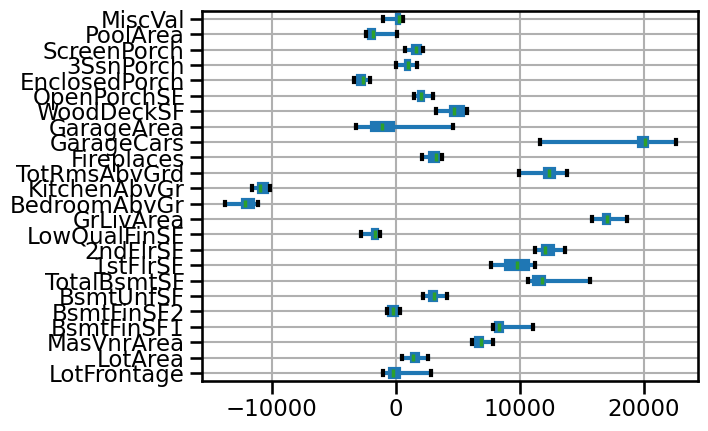

In [5]:
# study the distribution of the coefficients to identify most important features
coefs = []
for estimator in cv_results["estimator"]:
    ridge = estimator.named_steps["ridge"]
    coefs.append(ridge.coef_)

df = pd.DataFrame(coefs, columns=numerical_features)
df.boxplot(vert=False)

In [6]:
# RidgeCV example with RidgetCV and cross-validation to find the best alpha for each fold
from sklearn.linear_model import RidgeCV
import numpy as np
model = make_pipeline(
    StandardScaler(),
    RidgeCV(alphas=np.logspace(-3, 3, num=101))
) 

cv_results = cross_validate(
    model,
    data_numerical,
    target,
    cv=10,
    return_estimator=True,
    n_jobs=-1,
)

In [7]:
coefs = []
for estimator in cv_results["estimator"]:
    ridge = estimator.named_steps["ridgecv"]
    coefs.append(ridge.coef_)
df = pd.DataFrame(coefs, columns=numerical_features)
df.describe()

,LotFrontage,LotArea,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,...,Fireplaces,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal
count,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,...,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000
mean,743.339926,1733.169767,7203.658171,7443.521142,-425.141211,2962.574863,10572.306727,8484.937264,9538.043293,-1312.562242,...,5150.773925,12512.692089,6636.383440,5011.463311,3089.435802,-2537.281475,941.684802,1489.222732,-1057.740762,-66.619760
std,734.660873,430.052777,464.908727,1140.131155,280.804703,426.945480,1523.518355,421.534711,1150.085352,337.918298,...,831.237540,635.558420,454.812303,717.757668,399.807749,289.153494,431.398209,378.294878,408.721188,414.508376
min,38.652975,961.655936,6571.845907,6632.882723,-805.837310,2311.619975,9736.354859,7785.715524,8792.457560,-2105.446827,...,2937.176095,10855.560362,5900.709201,3510.073840,2444.831089,-3036.677405,104.433846,696.187449,-1509.761124,-1118.171765
25%,379.265042,1535.412158,6846.861008,6899.342451,-682.728683,2782.747213,9898.090497,8176.362749,9040.290828,-1341.904658,...,5068.401091,12460.603781,6319.098506,4794.773076,2892.937294,-2669.200003,927.865155,1326.300654,-1243.796301,-82.821871
50%,457.954298,1650.832662,7244.545273,7161.291222,-427.409639,2922.159529,10177.667684,8520.269997,9208.983632,-1228.532643,...,5382.654252,12645.445790,6538.268307,4961.971212,3024.917281,-2452.554273,1025.692632,1558.792853,-1135.786922,4.368648
75%,864.722508,1948.116524,7325.310010,7431.484323,-167.444508,3082.069599,10349.448927,8877.193689,9496.465484,-1135.907216,...,5552.196567,12719.424559,7045.843073,5626.997767,3220.375754,-2402.048436,1111.702582,1720.527611,-1043.610789,38.921539
max,2661.326993,2592.928650,7997.312361,10587.052511,-28.397411,3924.596537,14852.170471,8948.702031,12714.666357,-930.691632,...,5879.781189,13296.750348,7325.405214,5795.363926,3911.702621,-2096.896697,1559.553617,1986.348086,14.997116,554.961799


In [8]:
for estimator in cv_results["estimator"]:
    ridge = estimator.named_steps["ridgecv"]
    print(ridge.alpha_)

380.1893963205613
380.1893963205613
331.13112148259074
380.1893963205613
380.1893963205613
380.1893963205613
380.1893963205613
380.1893963205613
63.0957344480193
380.1893963205613


In [9]:
# check the test scores with only the numerical features
test_score_numeric = cv_results["test_score"]
test_score_numeric

array([0.77037446, 0.80154202, 0.80433727, 0.67735748, 0.76789802,
       0.76696435, 0.74846966, 0.70454089, 0.3305565 , 0.78763689])

In [10]:
# including non-numerical features
categorical_features = [
    "MSZoning", "Street", "Alley", "LotShape", "LandContour", "Utilities",
    "LotConfig", "LandSlope", "Neighborhood", "Condition1", "Condition2",
    "BldgType", "HouseStyle", "RoofStyle", "RoofMatl", "Exterior1st",
    "Exterior2nd", "MasVnrType", "ExterQual", "ExterCond", "Foundation",
    "BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2",
    "Heating", "HeatingQC", "CentralAir", "Electrical", "KitchenQual",
    "Functional", "FireplaceQu", "GarageType", "GarageFinish", "GarageQual",
    "GarageCond", "PavedDrive", "PoolQC", "Fence", "MiscFeature",
    "SaleType", "SaleCondition",
]

In [11]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)
model = make_pipeline(
    preprocessor,
    RidgeCV(alphas=np.logspace(-3, 3, num=101))
)

cv_results = cross_validate(
    model,
    data,
    target,
    cv=10,
    return_estimator=True,
    n_jobs=-1,
)

In [12]:
# check the test scores for each fold with all features
test_score_all_features = cv_results["test_score"]
test_score_all_features

array([0.90339315, 0.884019  , 0.87996011, 0.76479901, 0.88307756,
       0.8811061 , 0.87317774, 0.86917078, 0.55679486, 0.8858009 ])

In [13]:
# use SplineTransformer to model non-linear relationships
from sklearn.preprocessing import SplineTransformer
from sklearn.kernel_approximation import Nystroem

preprocessor = ColumnTransformer(
    transformers=[
        ("num", SplineTransformer(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)
model = make_pipeline(
    preprocessor,
    Nystroem(kernel="poly", n_components=300, random_state=0, degree=2),
    RidgeCV(alphas=np.logspace(-3, 3, num=101))
)

cv_results = cross_validate(
    model,
    data,
    target,
    cv=10,
    return_estimator=True,
    n_jobs=-1,
)

In [14]:
test_score_interaction = cv_results["test_score"]
test_score_interaction

array([0.90759275, 0.88383708, 0.90781911, 0.80639292, 0.86814436,
       0.89547686, 0.89539426, 0.88154961, 0.76132842, 0.89521548])

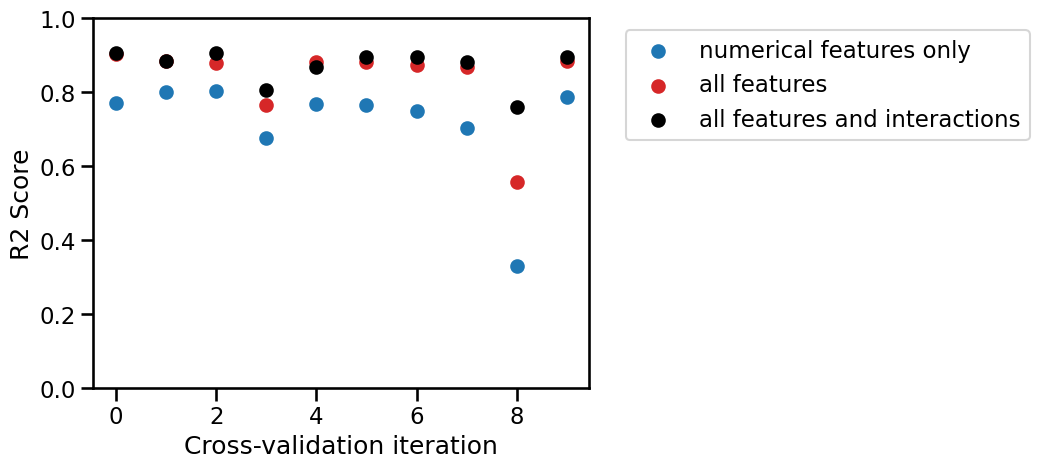

In [19]:
# compare the test scores with scatter plot
import matplotlib.pyplot as plt

indices = np.arange(len(test_score_numeric))

plt.scatter(
    indices,
    test_score_numeric,
    color="tab:blue",
    label="numerical features only"
)
plt.scatter(
    indices,
    test_score_all_features,
    color="tab:red",
    label="all features",
)
plt.scatter(
    indices,
    test_score_interaction,
    color="black",
    label="all features and interactions",
)

plt.ylim((0, 1))
plt.xlabel("Cross-validation iteration")
plt.ylabel("R2 Score")
_ = plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

plt.show()